In [26]:
import numpy as np
import matplotlib.pyplot as plt

# EXO1 :

In [27]:
def find_closest_centroids(X, centroids):

  idx = np.zeros(X.shape[0], dtype=int)

  ### START CODE HERE ###

  for i in range(X.shape[0]):
    distances = np.sum((X[i] - centroids)**2, axis=1) # sum the <<features>> per row ! for each <<centroid>>
    idx[i] = np.argmin(distances)

  ### END CODE HERE ###

  return idx

In [28]:
# Load an example dataset that we will be using
X = np.load("data/ex7_X.npy")

In [29]:
print("First five elements of X are:\n", X[:5])
print('The shape of X is:', X.shape)

First five elements of X are:
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]
The shape of X is: (300, 2)


In [30]:
# Select an initial set of centroids (3 Centroids)
initial_centroids = np.array([[3,3], [6,2], [8,5]])

# Find closest centroids using initial_centroids
idx = find_closest_centroids(X, initial_centroids)

# Print closest centroids for the first three elements
print("First three elements in idx are:", idx[:3])

First three elements in idx are: [0 2 1]


# EXO2 :

In [31]:
def compute_centroids(X, idx, K):
    # Useful variables
    m, n = X.shape

    # You need to return the following variables correctly
    centroids = np.zeros((K, n))

    ### START CODE HERE ###

    for k in range(K):
      points = X[idx == k] # select all the points that belong to the <<current centroid>>
      centroids[k] = np.mean(points, axis=0)

    ### END CODE HERE ##

    return centroids

In [32]:
K = 3
centroids = compute_centroids(X, idx, K)

print("The centroids are:", centroids)

The centroids are: [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


In [33]:
def draw_line(p1, p2, style="-k", linewidth=1):
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], style, linewidth=linewidth)

def plot_data_points(X, idx):
    # plots data points in X, coloring them so that those with the same
    # index assignments in idx have the same color
    plt.scatter(X[:, 0], X[:, 1], c=idx)

def plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i):
    # Plot the examples
    plot_data_points(X, idx)

    # Plot the centroids as black 'x's
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', c='k', linewidths=3)

    # Plot history of the centroids with lines
    for j in range(centroids.shape[0]):
        draw_line(centroids[j, :], previous_centroids[j, :])

    i=i+1
    plt.title("Iteration number %d" %i)

def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    """
    Runs the K-Means algorithm on data matrix X, where each row of X
    is a single example
    """

    # Initialize values
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids
    idx = np.zeros(m)

    # Run K-Means
    for i in range(max_iters):

        #Output progress
        print("K-Means iteration %d/%d" % (i+1, max_iters))

        # For each example in X, assign it to the closest centroid
        idx = find_closest_centroids(X, centroids)

        # Optionally plot progress
        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids

        # Given the memberships, compute new centroids
        centroids = compute_centroids(X, idx, K)
    plt.show()
    return centroids, idx

K-Means iteration 1/10
K-Means iteration 2/10
K-Means iteration 3/10
K-Means iteration 4/10
K-Means iteration 5/10
K-Means iteration 6/10
K-Means iteration 7/10
K-Means iteration 8/10
K-Means iteration 9/10
K-Means iteration 10/10


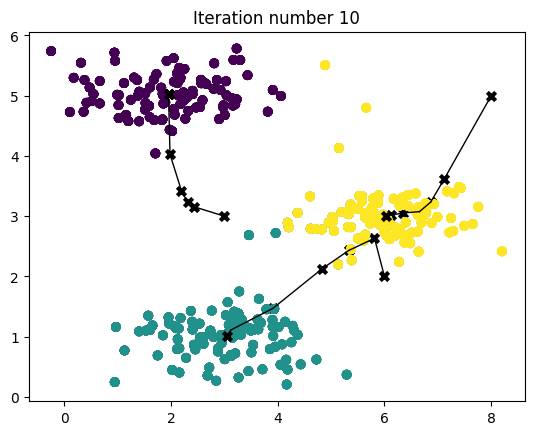

In [34]:
# Load an example dataset
X = np.load("data/ex7_X.npy")

# Set initial centroids
initial_centroids = np.array([[3,3],[6,2],[8,5]])
K = 3

# Number of iterations
max_iters = 10

centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

# EXO3 :

In [ ]:
def kMeans_init_centroids(X, K):
    """
    Initializes K centroids by randomly selecting K examples from X.
    """

    # START CODE HERE
    m = X.shape[0]

    # 1. <<shuffle indices>> <<m>>
    random_indices = np.random.permutation(m)

    # 2. pick first <<K examples>>
    centroids = X[random_indices[:K]]
    # END CODE HERE

    return centroids

# EXO4 :

In [36]:
def compute_distortion(X, centroids, idx):
    m = X.shape[0]
    cost = 0

    for i in range(m):
        cost += np.sum((X[i] - centroids[idx[i]])**2)

    return cost / m

In [38]:
# Assume X is your dataset, K is the number of clusters, and max_iters is defined
K = 3
max_iters = 20
n_runs = 5  # Number of random initializations to test

# Store results for each run
all_centroids = []
all_idx = []
all_distortions = []

for i in range(n_runs):

    print("Run", i)

    # 1. initialize centroids
    centroids = kMeans_init_centroids(X, K)

    for j in range(max_iters):

        # 2. assign points
        idx = find_closest_centroids(X, centroids)

        # 3. update centroids
        centroids = compute_centroids(X, idx, K)

    # 4. compute distortion
    distortion = compute_distortion(X, centroids, idx)

    # 5. store results
    all_centroids.append(centroids)
    all_idx.append(idx)
    all_distortions.append(distortion)

Run 0
Run 1
Run 2
Run 3
Run 4


### Do the final centroids and distortion values differ across runs?
- yes, in each iteration, we're initializing random centroid points, so in each iteration they converge to diff local minima (diff centroids + diff distortion)

# EXO5 : image compression with k-means :

In [85]:
# Load an image of a bird
# original_img = plt.imread('data/bird_small.png')

original_img = plt.imread('data/bird2.jpg')

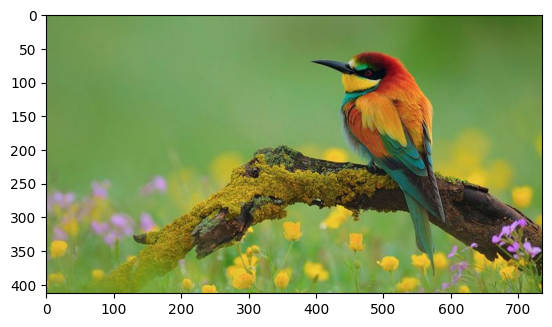

In [86]:
# Visualizing the image
plt.imshow(original_img)

In [87]:
print("Shape of original_img is:", original_img.shape)

Shape of original_img is: (413, 736, 3)


In [88]:
# Divide by 255 so that all values are in the range 0 - 1
original_img = original_img / 255

# Reshape the image into an m x 3 matrix where m = number of pixels
# (in this case m = 128 x 128 = 16384)
# Each row will contain the Red, Green and Blue pixel values
# This gives us our dataset matrix X_img that we will use K-Means on.

X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))

In [89]:
# START CODE HERE

K = 16
max_iters = 20

# 1. initialize centroids randomly from image pixels
centroids = kMeans_init_centroids(X_img, K)

# 2. run K-means
for i in range(max_iters):

    idx = find_closest_centroids(X_img, centroids)

    centroids = compute_centroids(X_img, idx, K)

# END CODE HERE

In [90]:
print("Shape of idx:", idx.shape)
print("Closest centroid for the first five elements:", idx[:5])

Shape of idx: (303968,)
Closest centroid for the first five elements: [3 3 3 3 3]


In [ ]:
# Represent image in terms of indices
X_recovered = centroids[idx, :] # <<rebuild>> the image <<(m, 3)>> by <<assigning each pixel to its cluster>> (rgb value)

# Reshape recovered image into proper dimensions
X_recovered = np.reshape(X_recovered, original_img.shape) # reshape back : (m, 3) -> (128, 128, 3)

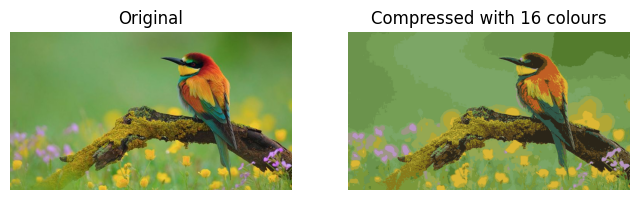

In [92]:
# Display original image
fig, ax = plt.subplots(1,2, figsize=(8,8))
plt.axis('off')

original_img = original_img*255
ax[0].imshow(original_img.astype(int))
ax[0].set_title('Original')
ax[0].set_axis_off()

X_recovered = X_recovered *255
# Display compressed image
ax[1].imshow(X_recovered.astype(int))
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()